In [36]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
import xarray as xr

In [38]:
df_uo = xr.open_dataset("../data/raw/adriatic_currents_uo_detided_2023_2024.nc")
df_vo = xr.open_dataset("../data/raw/adriatic_currents_vo_detided_2023_2024.nc")


In [39]:
import numpy as np
df_uo = df_uo[['longitude', 'latitude', 'uo_detided']].to_dataframe()
df_vo = df_vo[['longitude', 'latitude', 'vo_detided']].to_dataframe()
df_uo = df_uo[df_uo['uo_detided'].notna()]
df_vo = df_vo[df_vo['vo_detided'].notna()]


target_lat = 42.864690
target_lon = 17.694627

# get unique grid coordinates
coords = df_vo.index.droplevel("time").unique()

# convert to array for distance calc
lons = coords.get_level_values("longitude").to_numpy()
lats = coords.get_level_values("latitude").to_numpy()

dist = (lats - target_lat)**2 + (lons - target_lon)**2
i = dist.argmin()

nearest_lon = lons[i]
nearest_lat = lats[i]

print("Nearest grid point:", nearest_lat, nearest_lon)


Nearest grid point: 42.8125 17.666666


In [78]:
nearest_point_vo = df_vo.loc[(nearest_lon, nearest_lat)]
nearest_point_uo = df_uo.loc[(nearest_lon, nearest_lat)]

In [79]:
vo = nearest_point_vo.sort_index()
uo = nearest_point_uo.sort_index()

vo = vo.reset_index().rename(columns={"index": "time"})
uo = uo.reset_index().rename(columns={"index": "time"})

merged = (
    vo
    .merge(
        uo,
        on="time",
        how="left",
        sort=True,
        suffixes=("", "_uo"),
        validate="many_to_one",
    )
)

# restore DateTimeIndex
merged = merged.set_index("time")
merged

,vo_detided,uo_detided
time,,
2023-01-01,0.017474,-0.015320
2023-01-02,0.015987,-0.017746
2023-01-03,0.016359,-0.018181
2023-01-04,0.014173,-0.016384
2023-01-05,0.010407,-0.011324
...,...,...
2024-12-27,0.020214,-0.024052
2024-12-28,0.004118,-0.004657
2024-12-29,-0.001219,0.003540


In [80]:
import sys
sys.path.append("..")
from src.model.RBFNetwork import RBFNetwork

rbf = RBFNetwork(n_clusters=1)

In [93]:
y = merged[["vo_detided", "uo_detided"]].to_numpy()

In [94]:
x = np.array([nearest_lat, nearest_lon])

In [95]:
from scipy.spatial.distance import pdist
from sklearn.metrics import mean_squared_error, r2_score


coef = []
for day, y_time in enumerate(y):
    rbf.cluster_centers = np.array([nearest_lat, nearest_lon])
    rbf.spred = 1.0

    G_train = rbf._compute_rbf_activations(x, rbf.cluster_centers)  # x_scal
    rbf.model.fit(G_train, y_time)

    y_pred = rbf.model.predict(G_train)

    RMSE = np.sqrt(mean_squared_error(y_time, y_pred))
    R_sqer = r2_score(y_time, y_pred)

    coef.append(np.concatenate([rbf.model.coef_, np.array([rbf.model.intercept_])], axis=0))


In [96]:
coef = np.array(coef)
coef

array([[ 0.01639681, -0.01639681,  0.00107728],
       [ 0.01686661, -0.01686661, -0.00087947],
       [ 0.01727002, -0.01727002, -0.00091107],
       ...,
       [-0.0023797 ,  0.0023797 ,  0.00116048],
       [ 0.00119835, -0.00119835,  0.00266344],
       [ 0.00727356, -0.00727356,  0.00567538]], shape=(731, 3))

In [97]:
n = len(coef)
train = coef[:int(0.7*n)]
val   = coef[int(0.7*n):int(0.85*n)]
test  = coef[int(0.85*n):]


In [98]:
# from sklearn.preprocessing import StandardScaler
# import numpy as np

# scaler = StandardScaler()
# train = scaler.fit_transform(train)
# val = scaler.transform(val)
# test = scaler.transform(test)

Creae seq


In [99]:
import torch

def create_seq(ds, seq_length = 7):
    x, y = [], []
    for i in range(len(ds) - seq_length):
        x.append(ds[i: i+seq_length])
        y.append(ds[i+seq_length])
        
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

X_tensor_train, y_tensor_train = create_seq(train, seq_length = 7)
X_tensor_test, y_tensor_test = create_seq(test, seq_length = 7)

In [100]:
X_tensor_train.shape, y_tensor_train.shape

(torch.Size([504, 7, 3]), torch.Size([504, 3]))

In [101]:
from torch.utils.data import Dataset, DataLoader

class SeaCurrentDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_dataset = SeaCurrentDataset(X_tensor_train, y_tensor_train)
test_dataset = SeaCurrentDataset(X_tensor_test, y_tensor_test)

In [102]:
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [103]:
import torch.nn as nn

class LSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=64, output_size=3, num_layers=1,
                 lstm_dropout=0.0, post_lstm_dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0  # dropout only works for >1 layer
        )
        self.dropout = nn.Dropout(post_lstm_dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)           # (batch, seq_len, hidden_size)
        out = out[:, -1, :]             # last timestep
        out = self.dropout(out)         # post-LSTM dropout
        out = self.fc(out)
        return out


In [107]:
import torch
from sklearn.metrics import r2_score
from torch.nn.functional import huber_loss

num_epochs = 50 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Use device: {device}")

model = LSTM(input_size=3, hidden_size=128, output_size=3,
             num_layers=2, lstm_dropout=0.4, post_lstm_dropout=0.4)
model.to(device)
criterion = huber_loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

X = rbf._compute_rbf_activations(np.array([nearest_lat, nearest_lon]), rbf.cluster_centers)

for epoch in range(num_epochs):
    model.train()
    epoch_loss, epoch_r2, n_batches = 0.0, 0.0, 0
    
    train_true_y, train_pred_y = [], []
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X_batch)
        
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()

        train_true_y.extend(y_batch.detach().cpu().numpy().reshape(-1).tolist())
        train_pred_y.extend(y_pred.detach().cpu().numpy().reshape(-1).tolist())

        n_batches += 1
        
    train_loss = epoch_loss / n_batches
    train_r2 = r2_score(train_true_y, train_pred_y)

    model.eval()
    test_loss, test_r2, test_r2_unnorm, test_r2_uv, n_batches_test = 0.0, 0.0, 0.0, 0.0, 0
    

    test_true_y, test_pred_y = [], []
    test_original_true_y, test_original_pred_y = [], []
    test_true_uv, test_pred_uv = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            test_loss += loss.item()
            n_batches_test += 1
            test_true_y.extend(y_batch.detach().cpu().numpy().reshape(-1).tolist())
            test_pred_y.extend(y_pred.detach().cpu().numpy().reshape(-1).tolist())
            
            # inverse transform
            y_true_scaled = y_batch.detach().cpu().numpy()       # shape (batch, features)
            y_pred_scaled = y_pred.detach().cpu().numpy()       # same shape

            y_true_original=y_true_scaled
            y_pred_original=y_pred_scaled
            # y_true_original = scaler.inverse_transform(y_true_scaled)
            # y_pred_original = scaler.inverse_transform(y_pred_scaled)
            
            # test_original_true_y.extend(y_true_original.reshape(-1).tolist())
            # test_original_pred_y.extend(y_pred_original.reshape(-1).tolist())
            
            
            # UV prediction
            Y_pred_tru_list = []
            for coef in y_true_original:
                W_true = coef[:2*rbf.n_clusters].reshape(rbf.n_clusters, -1)
                B_true = coef[2*rbf.n_clusters:]
                Y_pred_tru = (X @ W_true.T) + B_true
                Y_pred_tru_list.append(Y_pred_tru[:, 0])

            Y_pred_UV = []
            for coef in y_pred_original:
                W_true = coef[:2*rbf.n_clusters].reshape(rbf.n_clusters, -1)
                B_true = coef[2*rbf.n_clusters:]
                Y_pred_tru = (X @ W_true.T) + B_true
                Y_pred_UV.append(Y_pred_tru[:, 0])
            
            y_true = np.vstack(Y_pred_tru_list)  # shape (num_samples, 2)
            y_pred = np.vstack(Y_pred_UV)       # same shape

            test_true_uv.extend(y_true.reshape(-1).tolist())
            test_pred_uv.extend(y_pred.reshape(-1).tolist())

    
    test_loss /= n_batches_test
    test_r2 = r2_score(test_true_y, test_pred_y)


    
    # test_r2_unnorm = r2_score(test_original_true_y, test_original_pred_y)
    test_r2_uv = r2_score(test_true_uv, test_pred_uv)


    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train Loss: {train_loss:.4f}, Train R2: {train_r2:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test R2: {test_r2:.4f} | "
        #   f"Test R2 unnorm: {test_r2_unnorm:.4f} | "
          f"Test R2 uv: {test_r2_uv:.4f} | ")
    
    


Use device: cpu
Epoch 1/50 - Train Loss: 0.0022, Train R2: 0.1227 | Test Loss: 0.0013, Test R2: -1.0795 | Test R2 uv: -1.0646 | 
Epoch 2/50 - Train Loss: 0.0019, Train R2: 0.2119 | Test Loss: 0.0010, Test R2: -0.6606 | Test R2 uv: -0.5990 | 
Epoch 3/50 - Train Loss: 0.0017, Train R2: 0.3089 | Test Loss: 0.0006, Test R2: -0.0666 | Test R2 uv: -0.0717 | 
Epoch 4/50 - Train Loss: 0.0013, Train R2: 0.4624 | Test Loss: 0.0004, Test R2: 0.2935 | Test R2 uv: 0.3173 | 
Epoch 5/50 - Train Loss: 0.0011, Train R2: 0.5595 | Test Loss: 0.0003, Test R2: 0.4293 | Test R2 uv: 0.4235 | 
Epoch 6/50 - Train Loss: 0.0010, Train R2: 0.6077 | Test Loss: 0.0002, Test R2: 0.6157 | Test R2 uv: 0.6112 | 
Epoch 7/50 - Train Loss: 0.0009, Train R2: 0.6331 | Test Loss: 0.0002, Test R2: 0.6247 | Test R2 uv: 0.6159 | 
Epoch 8/50 - Train Loss: 0.0010, Train R2: 0.6034 | Test Loss: 0.0003, Test R2: 0.4461 | Test R2 uv: 0.4384 | 
Epoch 9/50 - Train Loss: 0.0009, Train R2: 0.6414 | Test Loss: 0.0003, Test R2: 0.5842 | T

In [157]:
y_true = np.vstack(Y_pred_tru_list)  # shape (num_samples, 2)
y_pred = np.vstack(Y_pred_UV)       # same shape

# flatten both arrays to 1D
r2 = r2_score(y_true.flatten(), y_pred.flatten())
print("R2:", r2)


R2: 0.9802939242221679


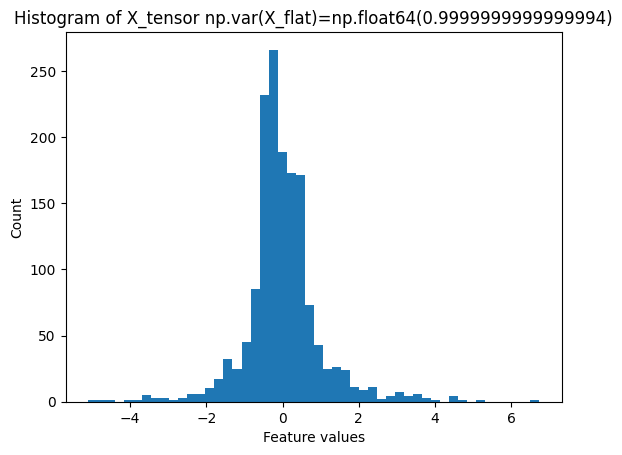

In [284]:
import matplotlib.pyplot as plt

X_flat = train.flatten()

plt.hist(X_flat, bins=50)  # adjust bins as needed
plt.xlabel("Feature values")
plt.ylabel("Count")
plt.title(f"Histogram of X_tensor {np.var(X_flat)=}")
plt.show()


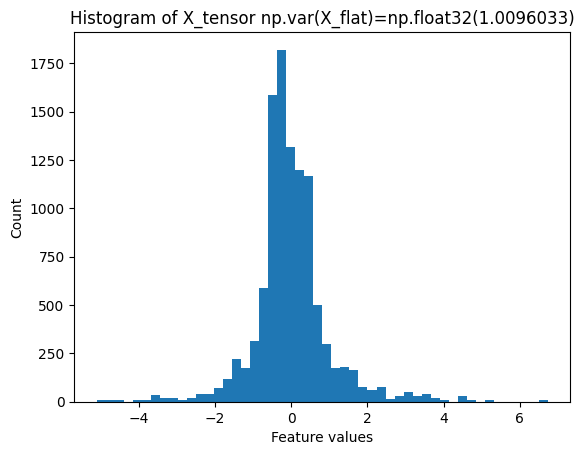

In [289]:
import matplotlib.pyplot as plt

# flatten all values
X_flat = X_tensor_train.numpy().flatten()

plt.hist(X_flat, bins=50)  # adjust bins as needed
plt.xlabel("Feature values")
plt.ylabel("Count")
plt.title(f"Histogram of X_tensor {np.var(X_flat)=}")
plt.show()


# row LSTM

In [68]:
y = merged[["vo_detided", "uo_detided"]].to_numpy()
y

array([[ 0.01747408, -0.01531953],
       [ 0.01598714, -0.01774608],
       [ 0.01635895, -0.01818109],
       ...,
       [-0.00121922,  0.00354018],
       [ 0.00386179,  0.00146509],
       [ 0.01294893, -0.00159818]], shape=(731, 2), dtype=float32)

In [69]:
n = len(y)
train = y[:int(0.7*n)]
val   = y[int(0.7*n):int(0.85*n)]
test  = y[int(0.85*n):]

In [70]:
# from sklearn.preprocessing import StandardScaler
# import numpy as np

# scaler = StandardScaler()
# train = scaler.fit_transform(train)
# val = scaler.transform(val)
# test = scaler.transform(test)

In [71]:
import torch

def create_seq(ds, seq_length = 7):
    x, y = [], []
    for i in range(len(ds) - seq_length):
        x.append(ds[i: i+seq_length])
        y.append(ds[i+seq_length])
        
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [72]:
X_tensor_train, y_tensor_train = create_seq(train, seq_length = 7)
X_tensor_test, y_tensor_test = create_seq(test, seq_length = 7)

In [73]:
from torch.utils.data import Dataset, DataLoader

class SeaCurrentDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [74]:
train_dataset = SeaCurrentDataset(X_tensor_train, y_tensor_train)
test_dataset = SeaCurrentDataset(X_tensor_test, y_tensor_test)

In [75]:
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [76]:
import torch.nn as nn

class LSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=64, output_size=3, num_layers=1,
                 lstm_dropout=0.0, post_lstm_dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=lstm_dropout if num_layers > 1 else 0.0  # dropout only works for >1 layer
        )
        self.dropout = nn.Dropout(post_lstm_dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)           # (batch, seq_len, hidden_size)
        out = out[:, -1, :]             # last timestep
        out = self.dropout(out)         # post-LSTM dropout
        out = self.fc(out)
        return out


In [77]:
import torch
from sklearn.metrics import r2_score
from torch.nn.functional import huber_loss

num_epochs = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Use device: {device}")

model = LSTM(input_size=2, hidden_size=256, output_size=2,
             num_layers=2, lstm_dropout=0.1, post_lstm_dropout=0.1)

model.to(device)
# criterion = torch.nn.MSELoss() #huber_loss
criterion = huber_loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(num_epochs):
    model.train()
    epoch_loss, epoch_r2, n_batches = 0.0, 0.0, 0
    
    train_true_y, train_pred_y = [], [] 
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        y_pred = model(X_batch)
        
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        train_true_y.extend(y_batch.detach().cpu().numpy().reshape(-1).tolist())
        train_pred_y.extend(y_pred.detach().cpu().numpy().reshape(-1).tolist())

        n_batches += 1
        
    train_loss = epoch_loss / n_batches
    train_r2 = r2_score(train_true_y, train_pred_y)
    
    model.eval()
    test_loss, test_r2, test_r2_unnorm, n_batches_test = 0.0, 0.0, 0.0, 0
    
    test_true_y, test_pred_y = [], [] 
    test_true_y_unnorm, test_pred_y_unnorm = [], [] 
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            test_loss += loss.item()
            test_true_y.extend(y_batch.detach().cpu().numpy().reshape(-1).tolist())
            test_pred_y.extend(y_pred.detach().cpu().numpy().reshape(-1).tolist())

            # r2 = r2_score(y_batch.detach().cpu().numpy().reshape(-1),
            #               y_pred.detach().cpu().numpy().reshape(-1))
            # test_r2 += r2

            y_true_scaled = y_batch.detach().cpu().numpy()       # shape (batch, features)
            y_pred_scaled = y_pred.detach().cpu().numpy()       # same shape

            # y_true_original = scaler.inverse_transform(y_true_scaled)
            # y_pred_original = scaler.inverse_transform(y_pred_scaled)
            # test_true_y_unnorm.extend(y_true_original)
            # test_pred_y_unnorm.extend(y_pred_original)
            # test_r2_unnorm += r2_score(y_true_original.flatten(), y_pred_original.flatten())

            n_batches_test+=1
            
    
    test_loss /= n_batches_test
    test_r2 = r2_score(test_true_y, test_pred_y)
    # test_r2_unnorm = r2_score(test_true_y_unnorm, test_pred_y_unnorm)
    # test_r2 /= n_batches_test
    # test_r2_unnorm /= n_batches_test


    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train Loss: {train_loss:.4f}, Train R2: {train_r2:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test R2: {test_r2:.4f} ")
        #   f"|  Test R2_norm: {test_r2_unnorm:.4f}")    
    


Use device: cpu
Epoch 1/20 - Train Loss: 0.0032, Train R2: 0.1506 | Test Loss: 0.0016, Test R2: -0.7019 
Epoch 2/20 - Train Loss: 0.0026, Train R2: 0.3245 | Test Loss: 0.0009, Test R2: 0.0669 
Epoch 3/20 - Train Loss: 0.0017, Train R2: 0.5545 | Test Loss: 0.0004, Test R2: 0.6029 
Epoch 4/20 - Train Loss: 0.0014, Train R2: 0.6218 | Test Loss: 0.0003, Test R2: 0.6486 
Epoch 5/20 - Train Loss: 0.0014, Train R2: 0.6403 | Test Loss: 0.0003, Test R2: 0.6591 
Epoch 6/20 - Train Loss: 0.0013, Train R2: 0.6609 | Test Loss: 0.0003, Test R2: 0.6943 
Epoch 7/20 - Train Loss: 0.0013, Train R2: 0.6620 | Test Loss: 0.0003, Test R2: 0.7111 
Epoch 8/20 - Train Loss: 0.0013, Train R2: 0.6712 | Test Loss: 0.0002, Test R2: 0.7465 
Epoch 9/20 - Train Loss: 0.0012, Train R2: 0.6851 | Test Loss: 0.0003, Test R2: 0.7190 
Epoch 10/20 - Train Loss: 0.0012, Train R2: 0.6830 | Test Loss: 0.0003, Test R2: 0.6643 
Epoch 11/20 - Train Loss: 0.0013, Train R2: 0.6730 | Test Loss: 0.0003, Test R2: 0.7121 
Epoch 12/20 -